<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/tears.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	train's auc: 0.824117	val's auc: 0.640318
Tier1: best_iter=32, val AUC ~ указан выше, карт=6120
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2]	train's auc: 0.699289	val's auc: 0.633065
Tier2: best_iter=2, val AUC ~ указан выше, карт=3295
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	train's auc: 0.790428	val's auc: 0.622685
Tier3: best_iter=13, val AUC ~ указан выше, карт=335


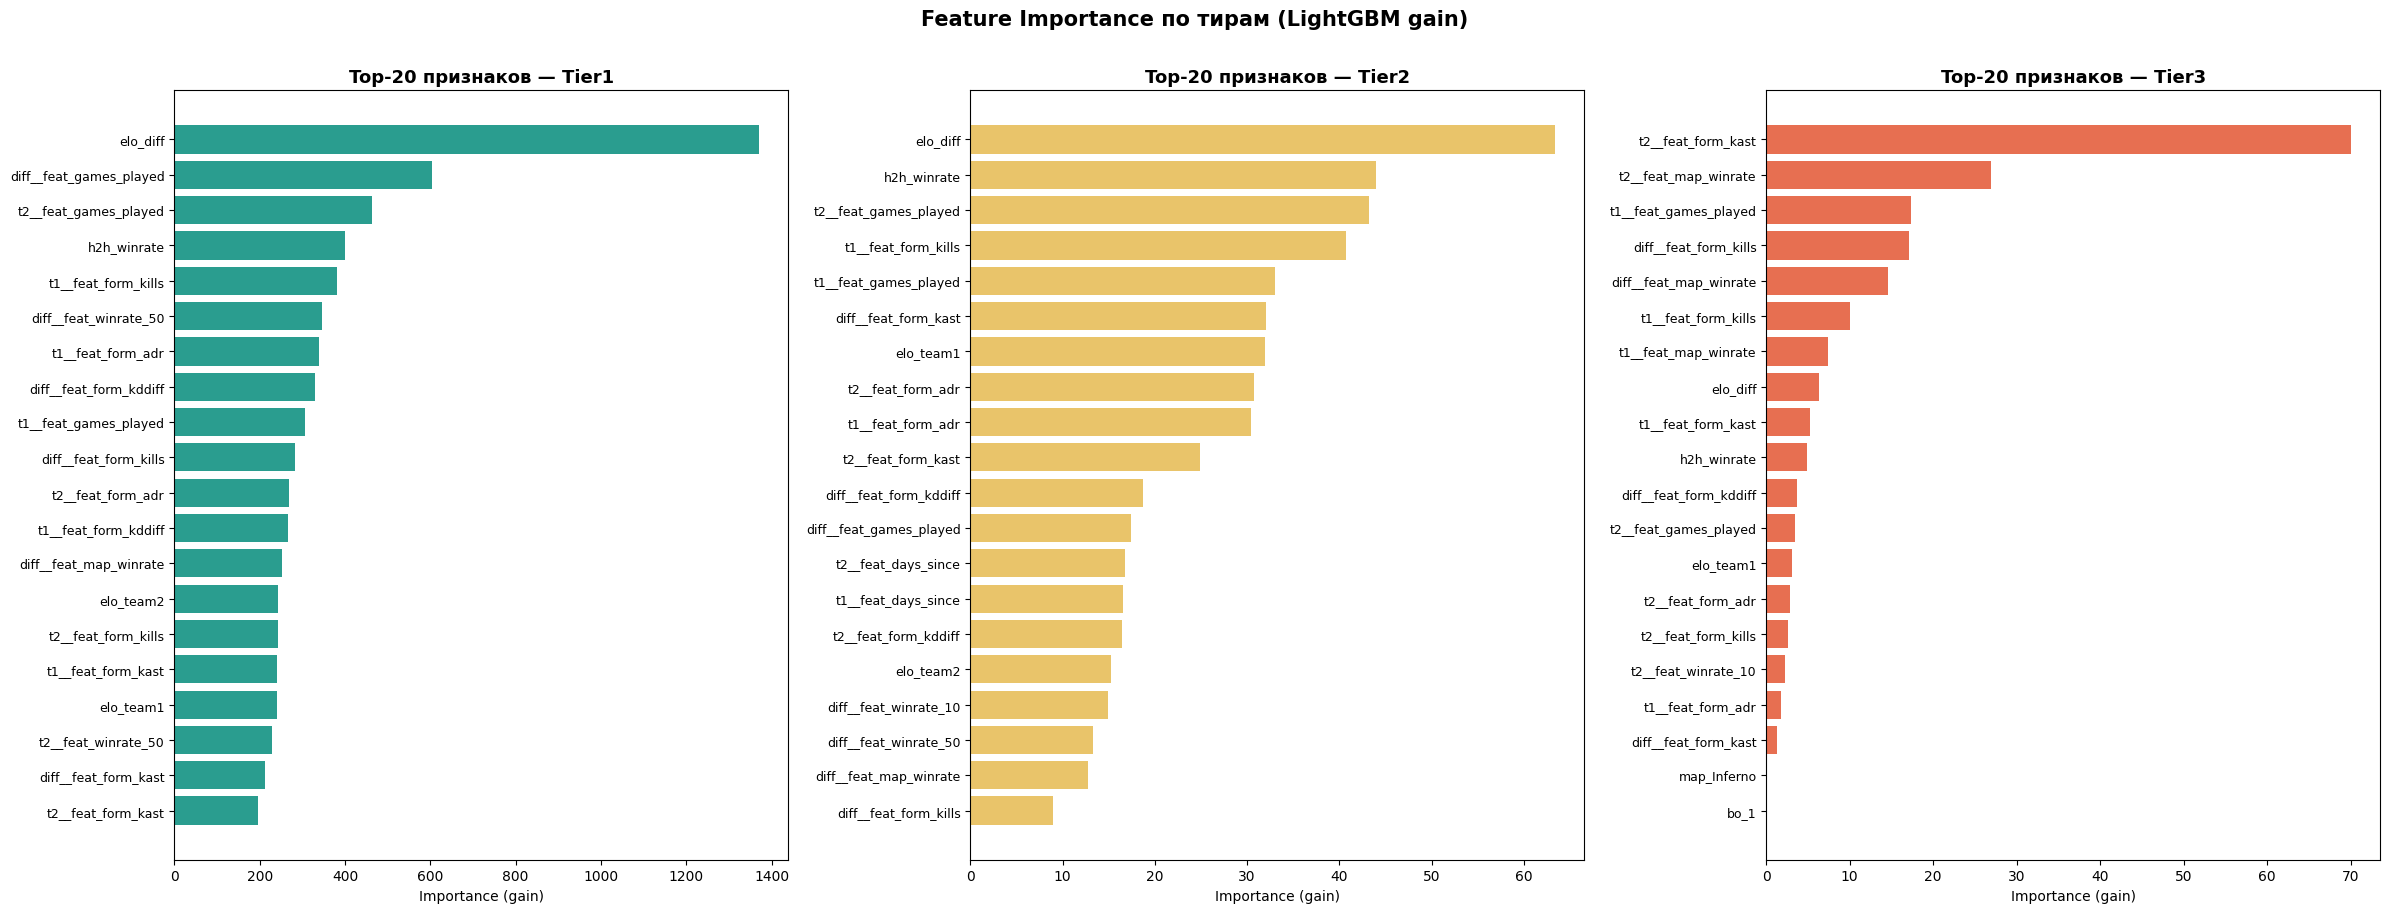

График сохранён: tier_feature_importance.png


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import lightgbm as lgb

warnings.filterwarnings('ignore')



DATA_DIR = '/data/'

games      = pd.read_csv(DATA_DIR + 'cs2_all_tiers_games.csv', index_col=0)
games_t1   = pd.read_csv(DATA_DIR + 'cs2_tier1_games.csv',     index_col=0)
games_t2   = pd.read_csv(DATA_DIR + 'cs2_tier2_games.csv',     index_col=0)
games_t3   = pd.read_csv(DATA_DIR + 'cs2_tier3_games.csv',     index_col=0)

games['datetime'] = pd.to_datetime(games['datetime'], errors='coerce')
games = games.drop_duplicates()

maps_df = games[games['is_total'] == False].copy()

t1_ids = set(games_t1['match_id'].unique())
t2_ids = set(games_t2['match_id'].unique())
t3_ids = set(games_t3['match_id'].unique())

def get_tier(mid):
    if mid in t1_ids: return 'Tier1'
    if mid in t2_ids: return 'Tier2'
    if mid in t3_ids: return 'Tier3'
    return 'Unknown'

maps_df['tier'] = maps_df['match_id'].apply(get_tier)
maps_df = maps_df.dropna(subset=[
    'score1_game', 'score2_game', 'map_name', 'team1_win', 'datetime', 'team1', 'team2'
])
maps_df = maps_df.sort_values('datetime').reset_index(drop=True)
maps_df['team1_win'] = maps_df['team1_win'].astype(int)


stat_cols = ['kills', 'deaths', 'assists', 'adr', 'kast', 'kddiff']
for stat in stat_cols:
    maps_df[f'team1_avg_{stat}'] = maps_df[[f'team1_player{i}_{stat}' for i in range(1, 6)]].mean(axis=1)
    maps_df[f'team2_avg_{stat}'] = maps_df[[f'team2_player{i}_{stat}' for i in range(1, 6)]].mean(axis=1)

def to_long(df):
    base = ['match_id', 'game_id', 'datetime', 'map_name', 'bestOf', 'tier']
    rows = []
    for persp, team_col, opp_col, win_col, score_col, opp_score_col in [
        ('team1', 'team1', 'team2', 'team1_win',     'score1_game', 'score2_game'),
        ('team2', 'team2', 'team1', 'team1_win',     'score2_game', 'score1_game'),
    ]:
        r = df[base].copy()
        r['team']        = df[team_col]
        r['opp']         = df[opp_col]
        r['win']         = df['team1_win'] if persp == 'team1' else 1 - df['team1_win']
        r['score']       = df[score_col]
        r['opp_score']   = df[opp_score_col]
        for s in stat_cols:
            r[s] = df[f'{persp}_avg_{s}']
        r['perspective'] = persp
        rows.append(r)
    return pd.concat(rows, ignore_index=True).sort_values('datetime').reset_index(drop=True)

long_df = to_long(maps_df)



def rolling_past(s, n):
    return s.shift(1).rolling(n, min_periods=1).mean()

long_df['feat_winrate_50']  = long_df.groupby('team')['win'].transform(lambda s: rolling_past(s, 50))
long_df['feat_winrate_10']  = long_df.groupby('team')['win'].transform(lambda s: rolling_past(s, 10))
long_df['feat_map_winrate'] = long_df.groupby(['team', 'map_name'])['win'].transform(lambda s: rolling_past(s, 20))
for s in ['adr', 'kast', 'kills', 'kddiff']:
    long_df[f'feat_form_{s}'] = long_df.groupby('team')[s].transform(lambda x: rolling_past(x, 20))
long_df['feat_games_played'] = long_df.groupby('team').cumcount()
long_df = long_df.sort_values(['team', 'datetime']).reset_index(drop=True)
long_df['feat_days_since'] = long_df.groupby('team')['datetime'].diff().dt.days
long_df = long_df.sort_values('datetime').reset_index(drop=True)



def compute_elo(df, k=32, start=1500):
    ratings = {}
    elo1, elo2 = [], []
    for t1, t2, win in zip(df['team1'].values, df['team2'].values, df['team1_win'].values):
        r1, r2 = ratings.get(t1, start), ratings.get(t2, start)
        elo1.append(r1); elo2.append(r2)
        e1 = 1 / (1 + 10 ** ((r2 - r1) / 400))
        ratings[t1] = r1 + k * (win       - e1)
        ratings[t2] = r2 + k * ((1 - win) - (1 - e1))
    return np.array(elo1), np.array(elo2)

elo1, elo2 = compute_elo(maps_df)
maps_df['elo_team1'] = elo1
maps_df['elo_team2'] = elo2
maps_df['elo_diff']  = elo1 - elo2


def compute_h2h(df, n=10):
    history, out = {}, []
    for t1, t2, win in zip(df.team1.values, df.team2.values, df.team1_win.values):
        key = tuple(sorted([t1, t2]))
        hist = history.get(key, [])
        recent = hist[-n:]
        out.append(sum(1 for w in recent if w == t1) / len(recent) if recent else 0.5)
        history.setdefault(key, []).append(t1 if win == 1 else t2)
    return out

maps_df['h2h_winrate'] = compute_h2h(maps_df)



feat_names = [c for c in long_df.columns if c.startswith('feat_')]

t1f = long_df[long_df.perspective == 'team1'][['match_id', 'game_id'] + feat_names].copy()
t1f.columns = ['match_id', 'game_id'] + [f't1__{c}' for c in feat_names]
t2f = long_df[long_df.perspective == 'team2'][['match_id', 'game_id'] + feat_names].copy()
t2f.columns = ['match_id', 'game_id'] + [f't2__{c}' for c in feat_names]

df = maps_df.merge(t1f, on=['match_id', 'game_id'], how='left')
df = df.merge(t2f, on=['match_id', 'game_id'], how='left')
for f in feat_names:
    df[f'diff__{f}'] = df[f't1__{f}'] - df[f't2__{f}']

df = pd.concat([df, pd.get_dummies(df['map_name'],                         prefix='map')],  axis=1)
df = pd.concat([df, pd.get_dummies(df['bestOf'].fillna(3).astype(int),     prefix='bo')],   axis=1)

feature_cols = (
    [f't1__{f}' for f in feat_names]
    + [f't2__{f}' for f in feat_names]
    + [f'diff__{f}' for f in feat_names]
    + ['elo_team1', 'elo_team2', 'elo_diff', 'h2h_winrate']
    + [c for c in df.columns if c.startswith('map_') and c not in ('map_name', 'map_id')]
    + [c for c in df.columns if c.startswith('bo_')]
)
feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))



TIERS     = ['Tier1', 'Tier2', 'Tier3']
TRAIN_END = pd.Timestamp('2025-07-01')
VAL_END   = pd.Timestamp('2026-01-01')

LGB_PARAMS = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    num_leaves=31, learning_rate=0.05,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1, random_state=42,
)

tier_models = {}

for tier in TIERS:
    sub = df[df['tier'] == tier].copy()
    train = sub[sub.datetime <  TRAIN_END]
    val   = sub[(sub.datetime >= TRAIN_END) & (sub.datetime < VAL_END)]

    if len(train) < 50 or len(val) < 10:
        print(f'{tier}: недостаточно данных (train={len(train)}, val={len(val)}), пропускаем')
        continue

    median_fill = train[feature_cols].median(numeric_only=True)
    X_tr = train[feature_cols].fillna(median_fill)
    y_tr = train['team1_win'].astype(int)
    X_vl = val[feature_cols].fillna(median_fill)
    y_vl = val['team1_win'].astype(int)

    ds_tr = lgb.Dataset(X_tr, y_tr)
    ds_vl = lgb.Dataset(X_vl, y_vl, reference=ds_tr)

    m = lgb.train(
        LGB_PARAMS, ds_tr,
        num_boost_round=500,
        valid_sets=[ds_tr, ds_vl], valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
    )
    tier_models[tier] = (m, feature_cols)
    print(f'{tier}: best_iter={m.best_iteration}, val AUC ~ указан выше, карт={len(sub)}')



n_tiers = len(tier_models)
fig, axes = plt.subplots(1, n_tiers, figsize=(8 * n_tiers, 9))
if n_tiers == 1:
    axes = [axes]

colors = {'Tier1': '#2a9d8f', 'Tier2': '#e9c46a', 'Tier3': '#e76f51'}

for ax, (tier, (m, fcols)) in zip(axes, tier_models.items()):
    imp = pd.DataFrame({
        'feature':    fcols,
        'importance': m.feature_importance(importance_type='gain'),
    }).sort_values('importance', ascending=True).tail(20)

    ax.barh(imp['feature'], imp['importance'], color=colors.get(tier, '#aaa'))
    ax.set_xlabel('Importance (gain)')
    ax.set_title(f'Top-20 признаков — {tier}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance по тирам (LightGBM gain)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tier_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: tier_feature_importance.png')
